<a href="https://colab.research.google.com/github/G-Abdusami/week14_lab/blob/main/Practical_Lab_SVM_NumPy_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [ ]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [ ]:
svm_np = LinearSVMFromScratch(C=1.0, learning_rate=0.001, n_iters=250)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [ ]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Explain hinge-loss gradient and max-margin intuition in comments/markdown.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

C=0.1, lr=0.001 → Accuracy=1.000
C=1.0, lr=0.001 → Accuracy=1.000
C=10.0, lr=0.0005 → Accuracy=1.000


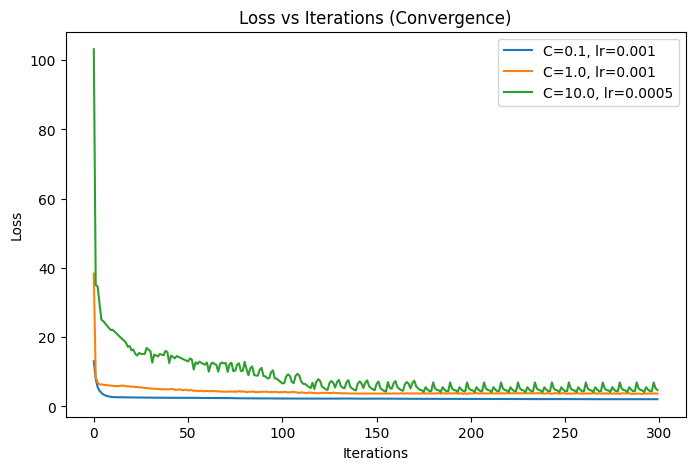

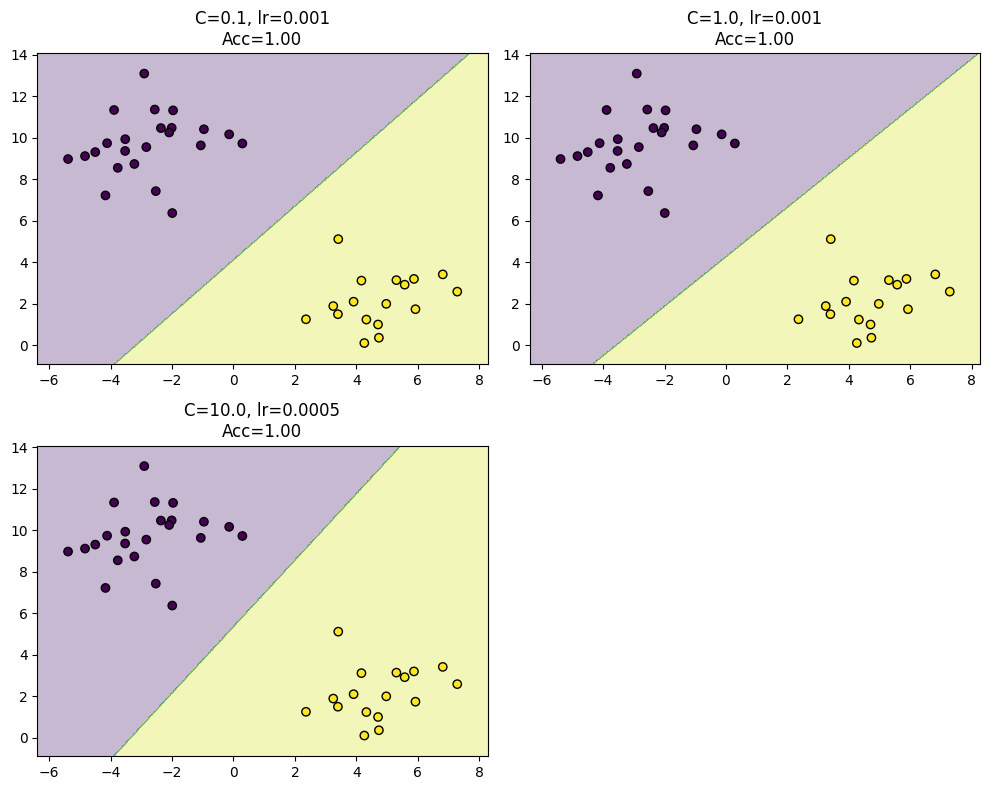

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================================================
# Linear Soft-Margin SVM (from scratch)
# =========================================================
class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    # BONUS: linear kernel (dot product)
    def linear_kernel(self, X1, X2):
        return np.dot(X1, X2.T)

    def fit(self, X, y):
        """
        Hinge Loss Objective:
        L = 1/2 ||w||^2 + C * Σ max(0, 1 - y_i (w·x_i + b))

        Subgradient:
        Case 1: y_i (w·x_i + b) >= 1
            → correctly classified with margin
            → gradient = w (only regularization)

        Case 2: y_i (w·x_i + b) < 1
            → margin violation
            → gradient = w - C*y_i*x_i
        """

        np.random.seed(self.random_state)

        n_samples, n_features = X.shape

        # Convert labels to {-1, +1}
        y = np.where(y <= 0, -1, 1)

        # Initialize parameters
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            loss = 0

            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b)

                if condition >= 1:
                    # Outside margin → only regularization
                    dw = self.w
                    db = 0
                else:
                    # Inside margin or misclassified
                    dw = self.w - self.C * y[i] * X[i]
                    db = -self.C * y[i]

                # Gradient descent update
                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

                # Hinge loss
                loss += max(0, 1 - condition)

            # Total loss
            total_loss = 0.5 * np.dot(self.w, self.w) + self.C * loss
            self.loss_history.append(total_loss)

        return self

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))


# =========================================================
# Dataset
# =========================================================
X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# Experiments (3+ hyperparameters)
# =========================================================
configs = [
    {"C": 0.1, "lr": 0.001},
    {"C": 1.0, "lr": 0.001},
    {"C": 10.0, "lr": 0.0005},
]

models = []
accuracies = []

plt.figure(figsize=(8, 5))

for cfg in configs:
    model = LinearSVMStudent(
        C=cfg["C"],
        learning_rate=cfg["lr"],
        n_iters=300
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    models.append(model)
    accuracies.append(acc)

    print(f"C={cfg['C']}, lr={cfg['lr']} → Accuracy={acc:.3f}")

    # Plot convergence
    plt.plot(model.loss_history, label=f"C={cfg['C']}, lr={cfg['lr']}")

plt.title("Loss vs Iterations (Convergence)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================================================
# Decision Boundary Plot
# =========================================================
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)

plt.figure(figsize=(10, 8))

for i, (model, cfg, acc) in enumerate(zip(models, configs, accuracies)):
    plt.subplot(2, 2, i+1)
    plot_decision_boundary(
        model, X_test, y_test,
        f"C={cfg['C']}, lr={cfg['lr']}\nAcc={acc:.2f}"
    )

plt.tight_layout()
plt.show()

### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use production-style sklearn workflow with `Pipeline`, scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build `Pipeline(StandardScaler + SVC)` for linear and RBF.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Use param names with pipeline prefix (e.g., `svc__C`, `svc__gamma`).
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Best params: {'svc__C': 0.1, 'svc__gamma': 0.1}

Model Comparison:
                    Model  Accuracy
0       NumPy Linear SVM       1.0
1     Sklearn Linear SVM       1.0
2  Sklearn RBF (untuned)       1.0
3    Sklearn RBF (tuned)       1.0


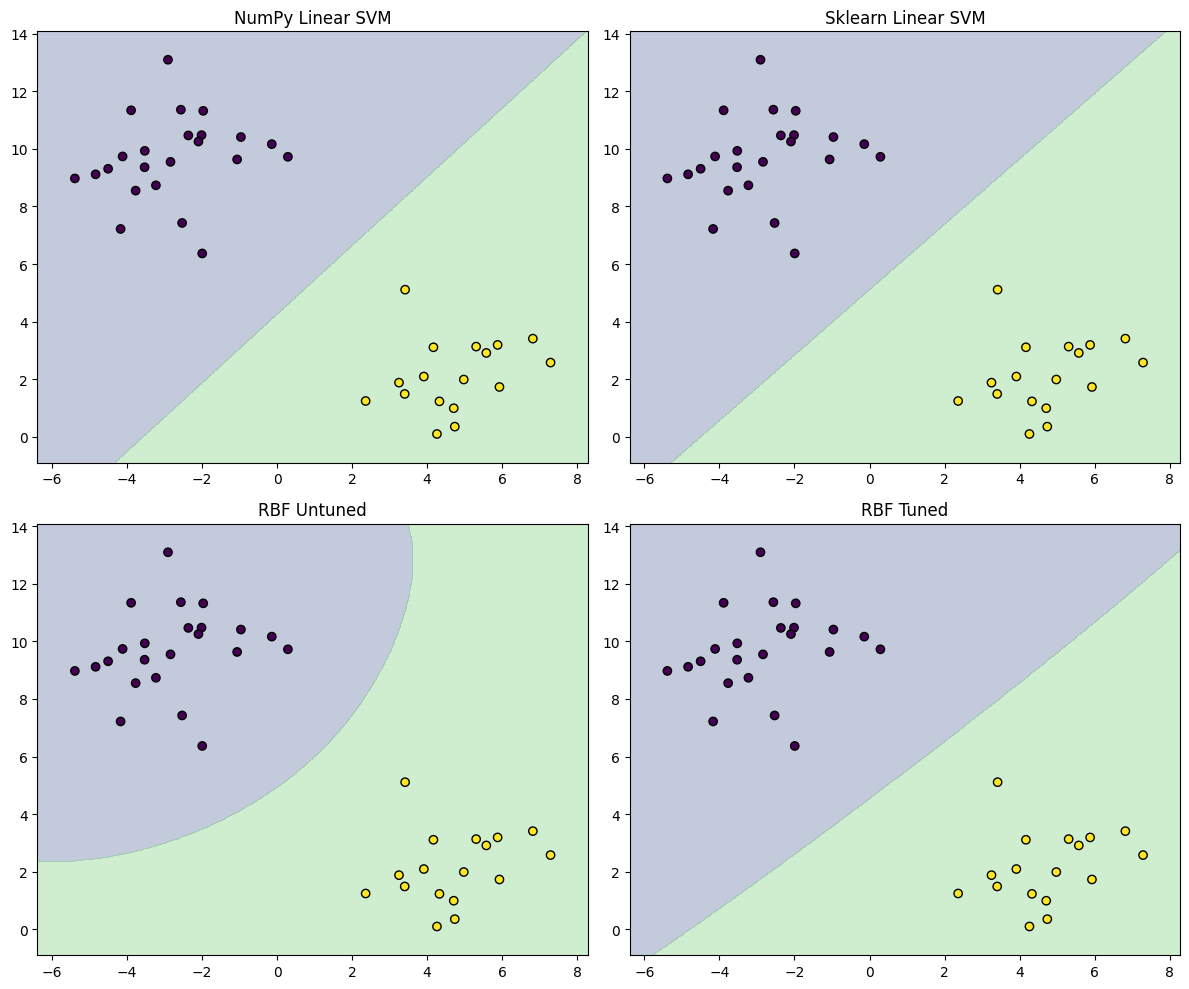

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

# =========================
# 1. NumPy SVM (from scratch)
# =========================
class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        y = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            loss = 0
            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b)

                if condition >= 1:
                    dw = self.w
                    db = 0
                else:
                    dw = self.w - self.C * y[i] * X[i]
                    db = -self.C * y[i]

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

                loss += max(0, 1 - condition)

            total_loss = 0.5 * np.dot(self.w, self.w) + self.C * loss
            self.loss_history.append(total_loss)

        return self

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))


# =========================
# 2. Dataset
# =========================
X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

y_signed = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test, y_train_signed, y_test_signed = train_test_split(
    X, y, y_signed, test_size=0.2, random_state=42
)

# =========================
# 3. Pipelines
# =========================
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

# =========================
# 4. Train Models
# =========================

# NumPy model
numpy_model = LinearSVMStudent()
numpy_model.fit(X_train, y_train_signed)
acc_numpy = accuracy_score(y_test_signed, numpy_model.predict(X_test))

# sklearn linear
linear_pipeline.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, linear_pipeline.predict(X_test))

# sklearn RBF (untuned)
rbf_pipeline.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, rbf_pipeline.predict(X_test))

# =========================
# 5. GridSearch (RBF tuned)
# =========================
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": [0.01, 0.1, 1]
}

grid = GridSearchCV(rbf_pipeline, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_
acc_rbf_tuned = accuracy_score(y_test, best_rbf.predict(X_test))

print("Best params:", grid.best_params_)

# =========================
# 6. Results Table
# =========================
results = pd.DataFrame({
    "Model": [
        "NumPy Linear SVM",
        "Sklearn Linear SVM",
        "Sklearn RBF (untuned)",
        "Sklearn RBF (tuned)"
    ],
    "Accuracy": [
        acc_numpy,
        acc_linear,
        acc_rbf,
        acc_rbf_tuned
    ]
})

print("\nModel Comparison:\n", results)

# =========================
# 7. Decision Boundary Plot
# =========================
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if hasattr(model, "decision_function"):
        Z = model.decision_function(grid)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z > 0, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)

# =========================
# 8. Plot all models
# =========================
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plot_decision_boundary(numpy_model, X_test, y_test_signed, "NumPy Linear SVM")

plt.subplot(2, 2, 2)
plot_decision_boundary(linear_pipeline, X_test, y_test, "Sklearn Linear SVM")

plt.subplot(2, 2, 3)
plot_decision_boundary(rbf_pipeline, X_test, y_test, "RBF Untuned")

plt.subplot(2, 2, 4)
plot_decision_boundary(best_rbf, X_test, y_test, "RBF Tuned")

plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report.
- Plot decision boundary using first two PCA components (or discuss feature behavior).
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Use `Pipeline` to avoid leakage.
- Keep one untouched test set for final evaluation.
- If PCA plot looks simplified, note that it is a 2D projection.
- Mention overfitting signs (very high train vs lower test performance).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

# =========================
# 1. Load Data
# =========================
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

print("Dataset shape:", X_bc.shape)
print("Target names:", bc.target_names)

# =========================
# 2. Train/Test Split (stratified)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc,
    test_size=0.2,
    stratify=y_bc,
    random_state=42
)

# =========================
# 3. Pipeline (Scaler + SVM)
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

# =========================
# 4. Hyperparameter Grid
# =========================
param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10]
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10],
        "svc__gamma": [0.001, 0.01, 0.1]
    }
]

# =========================
# 5. Grid Search
# =========================
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# =========================
# 6. Evaluation on Test Set
# =========================
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 7. PCA (2D visualization)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bc)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_bc,
    test_size=0.2,
    stratify=y_bc,
    random_state=42
)

# Train model on PCA data (for visualization only)
vis_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=grid.best_params_["svc__C"],
                gamma=grid.best_params_.get("svc__gamma", "scale")))
])

vis_model.fit(X_train_pca, y_train_pca)

# =========================
# 8. Decision Boundary Plot
# =========================
def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title("Decision Boundary (PCA Projection)")

plt.figure(figsize=(6, 5))
plot_decision_boundary(vis_model, X_test_pca, y_test_pca)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']

Best Parameters: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}

Evaluation Metrics:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:

[[41  1]
 [ 1 71]]


## 5) Additional Notebook Sections

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# =========================
# Metrics Table
# =========================
def metrics_table(y_true, y_pred, model_name="Model"):
    """
    Returns a clean DataFrame with evaluation metrics.
    Useful for comparing multiple models side-by-side.
    """
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })


# =========================
# Confusion Matrix Plot
# =========================
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    """
    Plots a confusion matrix heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


print("Helper functions ready.")

Helper functions ready.


### Reflection Questions
1. Why does RBF outperform linear on moons data? Because the moons dataset isn’t a straight-line problem. Linear SVM tries to draw a straight boundary and fails, while RBF can bend and fit the curved shape, so it works much better.
2. How does increasing `C` affect margin and errors? Higher C makes the model care more about avoiding mistakes, so it creates a tighter margin and fits training data closely. Lower C allows more errors but gives a wider margin.
3. How does `gamma` control complexity in RBF? Small gamma → smooth/simple boundary.
Large gamma → very detailed boundary that can overfit.
4. Why is scaling essential for SVM? Because SVM uses distances. If one feature has bigger values, it dominates everything. Scaling keeps all features balanced.
5. What did convergence plots reveal in your NumPy model? They showed the loss going down over time, so the model was learning. Also, some settings converged faster or more smoothly than others.